In [1]:
from pathlib import Path
import os
import sys

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
ga_path = project_root / "src" / "ga"
if str(ga_path) not in sys.path:
    sys.path.append(str(ga_path))

from src import fitness, load_image, population, rendering
from src.ga import GeneticAlgorithm, mutate, cross_over


In [2]:
individual = population.create_random_individual()
individual[:5]

[Triangle(x1=70, y1=180, x2=220, y2=71, x3=291, y3=285, r=211, g=246, b=0, a=197),
 Triangle(x1=149, y1=223, x2=76, y2=184, x3=41, y3=314, r=203, g=238, b=240, a=208),
 Triangle(x1=275, y1=157, x2=211, y2=191, x3=262, y3=118, r=50, g=237, b=104, a=22),
 Triangle(x1=208, y1=209, x2=184, y2=279, x3=71, y3=362, r=22, g=132, b=144, a=142),
 Triangle(x1=4, y1=262, x2=219, y2=325, x3=245, y3=58, r=36, g=224, b=217, a=138)]

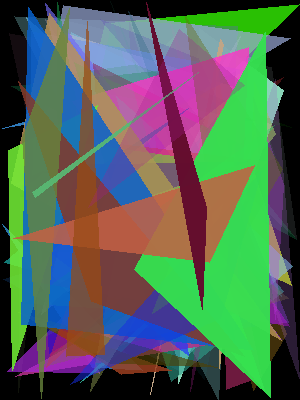

In [3]:
random_image = rendering.render_individual(individual=individual)
random_image

This random initialization confirms that the representation and rendering pipeline are functioning correctly.


In [4]:
# --- Import original paiting image --- #
image_path = os.path.join(project_root, "images/girl_pearl_earing.png")
target_array = load_image.load_target_image(image_path)
print(f"{target_array.shape} -> (H, W, 3) array with RGB values in [0, 255]")

(400, 300, 3) -> (H, W, 3) array with RGB values in [0, 255]


In [5]:
# --- Convert random first image to matrix and compute RMSE --- #
first_target_array = rendering.image_to_array(random_image)
fitness.compute_rmse(target=target_array, generated=first_target_array)

np.float32(81.305565)

In [7]:
ga = GeneticAlgorithm(
    target=target_array,
    fitness_function=fitness.compute_rmse,
    population_size=100,
    generations=300,
    crossover_function=cross_over.single_point_crossover,
    crossover_rate=0.9,
    mutation_function=mutate.random_triangle_mutation,
    mutation_rate=0.1,
    elitism=2,
    selection_type="roulette",
    logs=True,
    evaluation_backend="process",
    n_jobs=4,
    chunksize=5,
)

best_fitness, history = ga.run()
best_individual = ga.best_individual

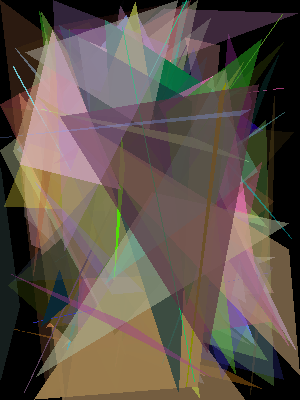

In [8]:
rendering.render_individual(individual=ga.best_individual)